# MorphEO WP1.3: Reference data collection

## Testing openEO

In [6]:
import openeo
import json
import os
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import glob
import pandas as pd
from datetime import datetime
import shapely.geometry

In [7]:
out_dir = '../data/output'

In [8]:
# connect to openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu/openeo/1.2").authenticate_oidc()

Authenticated using refresh token.


## Exploring glacial lake and lava flow datasets for Iceland

### Glacial lake data

#### Little practice with NDWI

In [9]:
# define aoi
jok_aoi = json.load(open('../data/preliminary/jokulsarlon_aoi.geojson'))
region = jok_aoi['features'][0]['geometry']
geom = shapely.geometry.shape(region)

In [10]:
# define time period
time_period = ['2023-07-01', '2023-07-31']

In [11]:
s2 = conn.load_collection(
    'SENTINEL2_L1C',
    spatial_extent=geom,
    temporal_extent=time_period,
    bands=["B02", "B03", "B04", "B08"]
)

In [12]:
# Calculate NDWI
green = s2.band('B03')
nir = s2.band('B08')
ndwi = (green - nir) / (green + nir)
ndwi.mask_polygon(mask=geom)

In [13]:
# Download the result
#ndwi.download(os.path.join(out_dir, 'ndwi.nc'))

<xarray.Dataset> Size: 222MB
Dimensions:  (t: 18, x: 1532, y: 2010)
Coordinates:
  * t        (t) datetime64[ns] 144B 2023-07-02 2023-07-04 ... 2023-07-30
  * x        (x) float64 12kB 4.297e+05 4.297e+05 ... 4.45e+05 4.45e+05
  * y        (y) float64 16kB 7.115e+06 7.115e+06 ... 7.095e+06 7.095e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 222MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


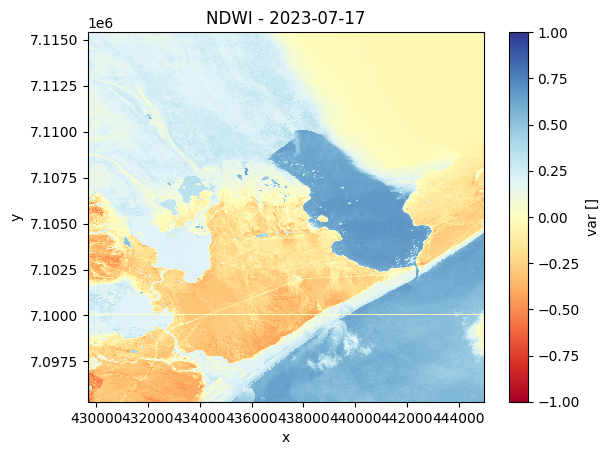

In [14]:
# save png
ndwi_ds = xr.open_dataset('../data/output/ndwi.nc')

print(ndwi_ds)
ndwi_data = ndwi_ds['var'].isel(t=9)

fig, ax = plt.subplots()
ndwi_data.plot(cmap='RdYlBu', vmin=-1, vmax=1)
plt.title(f"NDWI - {str(ndwi_data.t.values)[:10]}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.savefig('../data/output/ndwi.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()



### Lava flow data
---

#### Little practice with NHI

---

In [15]:
# define aoi
f_aoi = json.load(open('../data/preliminary/fagradalsfjall_aoi.geojson'))
f_region = f_aoi['features'][0]['geometry']
f_geom = shapely.geometry.shape(f_region)

In [16]:
# define time period
time_period = ['2022-08-01', '2022-08-31']

In [17]:
s2 = conn.load_collection(
    'SENTINEL2_L1C',
    spatial_extent=f_geom,
    temporal_extent=time_period,
    bands=["B08", "B11"]
)

Normalized Hotspot Index [Falconieri et al 2022](https://doi.org/10.3390/rs14215481)

In [18]:
nir = s2.band("B08")
swir1 = s2.band("B11")
nhi = (swir1 - nir) / (swir1 + nir)
nhi.mask_polygon(mask=f_geom)


In [19]:
## Download the result
#nhi.download(os.path.join(out_dir, 'nhi.nc'))

<xarray.Dataset> Size: 112MB
Dimensions:  (t: 18, x: 1305, y: 1190)
Coordinates:
  * t        (t) datetime64[ns] 144B 2022-08-02 2022-08-03 ... 2022-08-30
  * x        (x) float64 10kB 4.279e+05 4.279e+05 ... 4.41e+05 4.41e+05
  * y        (y) float64 10kB 7.089e+06 7.089e+06 ... 7.077e+06 7.077e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 112MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  openEO platform


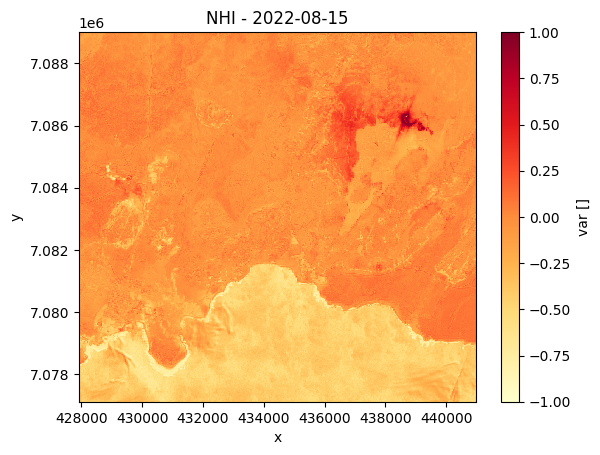

In [20]:
# save png
nhi_ds = xr.open_dataset('../data/output/nhi.nc')

print(nhi_ds)
nhi_data = nhi_ds['var'].isel(t=8)

fig, ax = plt.subplots()
nhi_data.plot(cmap='YlOrRd', vmin=-1, vmax=1)
plt.title(f"NHI - {str(nhi_data.t.values)[:10]}")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.savefig('../data/output/nhi.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

#### Lava outlines from [Gunnarson et al 2023](https://zenodo.org/records/7871187)

---

Load .gpkg files, extract file names, and reproject to UTM 27N

In [21]:
folder = r'..\data\preliminary\lava_outline_20220803-20220926'
files = glob.glob(os.path.join(folder, 'lava_outline_*.gpkg'))

gdfs = []
for fp in sorted(files):
    basename = os.path.basename(fp)
    # extract date: lava_outline_YYYYMMDD_...
    date_str = basename.split('_')[2]          # '20220803'
    date = datetime.strptime(date_str, '%Y%m%d').date()

    gdf = gpd.read_file(fp)
    gdf = gdf.to_crs('EPSG:32627')            # reproject from EPSG:3057 → UTM 27N
    gdf['date'] = pd.to_datetime(date)
    gdf['source_file'] = basename
    gdfs.append(gdf)

Combine lava outlines into a single geodataframe

In [22]:
combined = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs='EPSG:32627')
combined = combined.sort_values('date').reset_index(drop=True)

print(combined[['date', 'source_file', 'geometry']].to_string())
print(f"\n{len(combined)} outlines loaded, {combined['date'].nunique()} unique dates")

out_path = r'..\data\output\lava_outlines.gpkg'
combined.to_file(out_path, driver='GPKG')
print(f"Saved → {out_path}")

        date                                              source_file                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Plot matching dates of lava outlines and S2

In [23]:
for i in range(len(nhi_ds.t)):
    nhi_data = nhi_ds['var'].isel(t=i)
    nhi_date = pd.Timestamp(nhi_data.t.values).date()

    matched = combined[combined['date'].dt.date == nhi_date]
    if matched.empty:
        print(f"No lava outline for {nhi_date}, skipping")
        continue
    
    fig, ax = plt.subplots(figsize=(8, 6))
    nhi_data.plot(ax=ax, cmap='YlOrRd', vmin=-1, vmax=1)
    matched.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2,
                 label=f"Lava {matched['date'].dt.date.iloc[0]}")
    ax.legend()
    plt.title(f"NHI with lava outline — {nhi_date}")
    plt.savefig(f'../data/output/nhi_lava_{nhi_date}.png', bbox_inches='tight')
    plt.close()
    print(f"Saved plot for {nhi_date}")

No lava outline for 2022-08-02, skipping


C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'../data/output/nhi_lava_{nhi_date}.png', bbox_inches='tight')


Saved plot for 2022-08-03
No lava outline for 2022-08-05, skipping
No lava outline for 2022-08-07, skipping
No lava outline for 2022-08-08, skipping
No lava outline for 2022-08-10, skipping
No lava outline for 2022-08-12, skipping


C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'../data/output/nhi_lava_{nhi_date}.png', bbox_inches='tight')


Saved plot for 2022-08-13


C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\b1120440\AppData\Local\Temp\ipykernel_23696\3389202444.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'../data/output/nhi_lava_{nhi_date}.png', bbox_inches='tight')


Saved plot for 2022-08-15
No lava outline for 2022-08-17, skipping
No lava outline for 2022-08-18, skipping
No lava outline for 2022-08-20, skipping
No lava outline for 2022-08-22, skipping
No lava outline for 2022-08-23, skipping
No lava outline for 2022-08-25, skipping
No lava outline for 2022-08-27, skipping
No lava outline for 2022-08-28, skipping
No lava outline for 2022-08-30, skipping
